In [1]:
using Interpolations
using Polynomials
using Plots

In [2]:
@Base.kwdef struct Vaxsched
    dayrange::UnitRange{Int64}
    targetpct::Float64
    shape::Vector{Float64} = [0.0, .02, .05, .10, .15, .19, 
        .21, .16, .08, .03, .01]
end

Vaxsched

In [3]:
sch1 = Vaxsched(dayrange=45:300,targetpct=0.85)

Vaxsched(45:300, 0.85, [0.0, 0.02, 0.05, 0.1, 0.15, 0.19, 0.21, 0.16, 0.08, 0.03, 0.01])

In [4]:
abstract type Vaccine end

    @Base.kwdef mutable struct Pfizer <: Vaccine
        name::Symbol = :Pfizer
        shots::Int
        halflife::Int
        send_risk::Vector{Float64}
        recv_risk::Vector{Float64}
    end

Pfizer

In [10]:
pf = Pfizer(shots=2,halflife=720,send_risk=Float64[], recv_risk=Float64[])

Pfizer(:Pfizer, 2, 720, Float64[], Float64[])

In [11]:
pf.send_risk = [0.00, 0.30, 0.65, 0.75, 0.85, 0.85, 0.75, 0.70, 0.65, 0.6, 
             0.50, 0.20, 0.10, 0.10, 0.10, 0.05, 0.05, 0.00, 0.00, 0.0, 
             0.00, 0.00, 0.00, 0.00, 0.00] .* .5

25-element Vector{Float64}:
 0.0
 0.15
 0.325
 0.375
 0.425
 0.425
 0.375
 0.35
 0.325
 0.3
 0.25
 0.1
 0.05
 0.05
 0.05
 0.025
 0.025
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [12]:
function makevax(vx::Vaxsched)
    schedlength = length(vx.dayrange)
    shapescale = vx.shape .* ((length(vx.shape)-1)/schedlength)
    interp = LinearInterpolation(0:length(shapescale)-1, shapescale)
    startday = vx.dayrange.start; endday = vx.dayrange.stop
    return  function vaxsched(day)
                @assert startday <= day <= endday "Day not in dayrange $(vx.dayrange)"
                p = (day - startday + 1) * round((length(interp)-1) / schedlength, digits=4)
                return interp(p) * vx.targetpct
            end
end

makevax (generic function with 1 method)

In [13]:
maxpct = .85
shape = [0.0, .02, .05, .10, .15, .19, .21, .16, .08, .03, .01]
@show sum(shape), length(shape)
xs = 91:360
id = collect(0:10)
order = 10
shapescale = shape .* ((length(shape)-1)/length(xs))

(sum(shape), length(shape)) = (1.0, 11)


11-element Vector{Float64}:
 0.0
 0.0007407407407407407
 0.001851851851851852
 0.003703703703703704
 0.005555555555555555
 0.007037037037037037
 0.007777777777777777
 0.005925925925925926
 0.002962962962962963
 0.0011111111111111111
 0.00037037037037037035

In [14]:
vx = Vaxsched(dayrange=xs, targetpct=maxpct, shape=shape)
dump(vx)

Vaxsched
  dayrange: UnitRange{Int64}
    start: Int64 91
    stop: Int64 360
  targetpct: Float64 0.85
  shape: Array{Float64}((11,)) [0.0, 0.02, 0.05, 0.1, 0.15, 0.19, 0.21, 0.16, 0.08, 0.03, 0.01]


## Interpolate with polynomial fit

In [15]:
px = fit(collect(0:length(shapescale)-1), shapescale, order)

Polynomial(-0.009215167548500814*x + 0.028156628453850495*x^2 - 0.032126310503625126*x^3 + 0.019659291511529054*x^4 - 0.007133680555555516*x^5 + 0.0016088906035665214*x^6 - 0.00022760508524397304*x^7 + 1.9614687438761418e-5*x^8 - 9.400107779737364e-7*x^9 + 1.9188059311516012e-8*x^10)

In [16]:
function relx(p, shape, xs) 
    startday = first(xs); endday = last(xs)
    @assert startday <= p <= endday "Day not in startday to endday"
    (p - startday + 1) * round(((length(shape)-1) / length(xs)), digits=4)
end

relx (generic function with 1 method)

In [17]:
relx(101, shapescale, xs)

0.407

In [18]:
11/270

0.040740740740740744

In [19]:
allx = [relx(i, shape, xs) for i in xs]

270-element Vector{Float64}:
 0.037
 0.074
 0.11099999999999999
 0.148
 0.185
 0.22199999999999998
 0.259
 0.296
 0.33299999999999996
 0.37
 0.407
 0.44399999999999995
 0.481
 ⋮
 9.583
 9.62
 9.657
 9.693999999999999
 9.731
 9.767999999999999
 9.805
 9.841999999999999
 9.879
 9.916
 9.953
 9.99

In [20]:
py = px.(allx)

270-element Vector{Float64}:
 -0.0003040057148409132
 -0.0005401811066265247
 -0.0007170355421699545
 -0.0008423065777294955
 -0.0009230122443912767
 -0.0009655006750450224
 -0.0009754971724111678
 -0.0009581488149742362
 -0.0009180666951168547
 -0.0008593658812307309
 -0.00078570319310503
 -0.0007003128774585204
 -0.0006060402680892794
  ⋮
 -0.0009771630270517873
 -0.001070783753433401
 -0.0011426460332241684
 -0.0011877592793780418
 -0.001200528087618942
 -0.0011747043527532493
 -0.0011033367481571403
 -0.0009787174622185287
 -0.0007923260882772404
 -0.0005347705625830848
 -0.00019572503449353024
  0.00023613543902421198

In [21]:
py .= max.(0.0, py)

270-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.00023613543902421198

In [22]:
sum(py)

0.9847289568754225

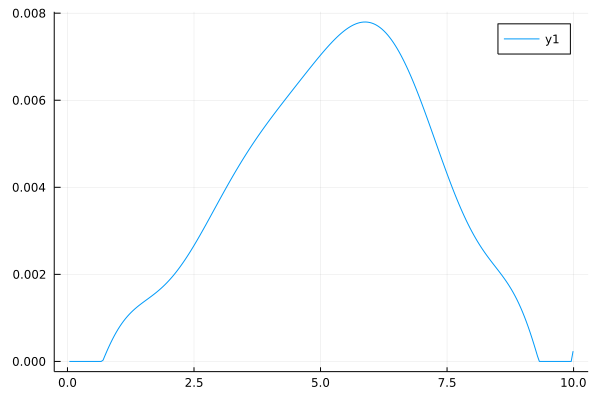

In [23]:
# This is too artificial
plot(allx, py)

In [24]:
@show allx[length(xs)] py[length(xs)]

allx[length(xs)] = 9.99
py[length(xs)] = 0.00023613543902421198


0.00023613543902421198

In [25]:
sum(py .* .65 .* 330_000_000)

2.1122436124977812e8

In [26]:
327_000_000

327000000

## piecewise linear

In [27]:
interp = LinearInterpolation(0:length(shapescale)-1, shapescale)

11-element extrapolate(scale(interpolate(::Vector{Float64}, BSpline(Linear())), (0:10,)), Throw()) with element type Float64:
 0.0
 0.0007407407407407407
 0.001851851851851852
 0.003703703703703704
 0.005555555555555555
 0.007037037037037037
 0.007777777777777777
 0.005925925925925926
 0.002962962962962963
 0.0011111111111111111
 0.00037037037037037035

In [28]:
interp.(allx)[1]

2.7407407407407347e-5

In [29]:
vaxsched = makevax(vx)

vaxsched (generic function with 1 method)

In [30]:
vaxsched(91)

2.3296296296296243e-5

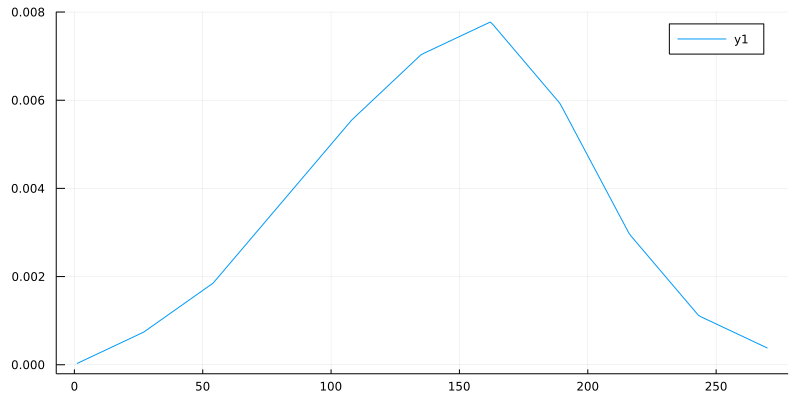

In [31]:
plot(interp(allx), size=(800,400))

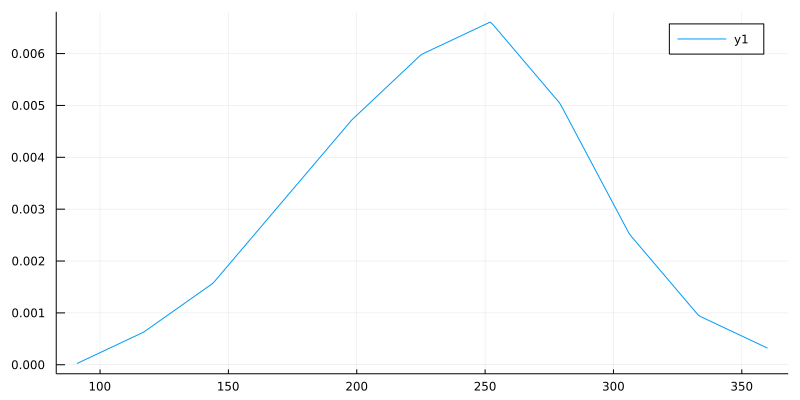

In [32]:
plot(xs,vaxsched.(xs), size=(800,400))

In [33]:
sum(vaxsched.(xs))

0.846668